# 391 — Compare features across class types

Six figures that compare the **feature variants** against the **class types**
(condition / Yeo-7 / Yeo-17) and classifiers. Reads the runs 320/330 wrote — no new
computation. Run 320 + 330 first, then this.

> **The rule every panel obeys:** chance differs by task (0.33 / 0.14 / 0.06), so balanced
> accuracy is **never** shared across tasks on one axis — a taller Yeo-17 bar than condition
> would be a lie. Figs 2–4 share one axis using **fraction above chance** = `(BA − chance) /
> (1 − chance)` — bounded 0–1, comparable across tasks, and it carries a real **bootstrap 95%
> CI**, so the panels can show honest **error bars**. (A z-score *can't*: its CI is ±1.96 by
> construction — and the permutation-null z blows up to z≈50–390 for random-forest on the
> parcellation tasks. The Wald z is kept in the table for reference.) Figs 5–6 open up the
> **confusion matrices** (per task — the class sets differ, so they can't be merged), and a
> closing cell **tests HG vs FULL** per task. Styled with **seaborn** (falls back to
> matplotlib's seaborn theme if seaborn isn't installed).


In [1]:
import sys, importlib
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))
from functions import lf_classify as C
importlib.reload(C)            # pick up any edits to lf_classify without restarting the kernel
import matplotlib.pyplot as plt
from IPython.display import display

comp = C.compare_table()
outdir = C.OUTPUTS_ROOT / '_compare'; outdir.mkdir(parents=True, exist_ok=True)
if not len(comp):
    print('no runs yet — run 320 and 330 first.')
else:
    print(f'{len(comp)} runs · {comp.task.nunique()} tasks · {comp.variant.nunique()} variants')
    display(comp[['task','variant','classifier','balanced_accuracy','chance_level',
                  'above_chance','z_score','permutation_p']].round(3))


56 runs · 3 tasks · 10 variants


,task,variant,classifier,balanced_accuracy,chance_level,above_chance,z_score,permutation_p
0,condition,full_30,logreg,0.561,0.333,0.341,8.593,0.005
1,condition,full_30,rf,0.476,0.333,0.214,3.832,0.005
2,condition,hg_30,logreg,0.506,0.333,0.259,7.108,0.005
3,condition,hg_30,rf,0.529,0.333,0.293,7.707,0.005
4,condition,m101_300,logreg,0.440,0.333,0.160,5.524,0.005
5,condition,m101_300,rf,0.487,0.333,0.231,5.459,0.005
6,condition,m101_30,logreg,0.420,0.333,0.130,3.418,0.005
7,condition,m101_30,rf,0.499,0.333,0.249,5.847,0.005
8,parcellation_yeo7,m101_300,logreg,0.213,0.143,0.082,2.642,0.005
9,parcellation_yeo7,m101_300,rf,0.262,0.143,0.139,4.282,0.005


## Fig 1 — Master heatmap (the one-glance overview)
Rows = variant, cols = task × classifier. Cell colour = **fraction above chance**;
annotation = balanced accuracy (`*` = p<.05). Read across a row to see where a feature wins,
down a column to see which feature wins for that class type.


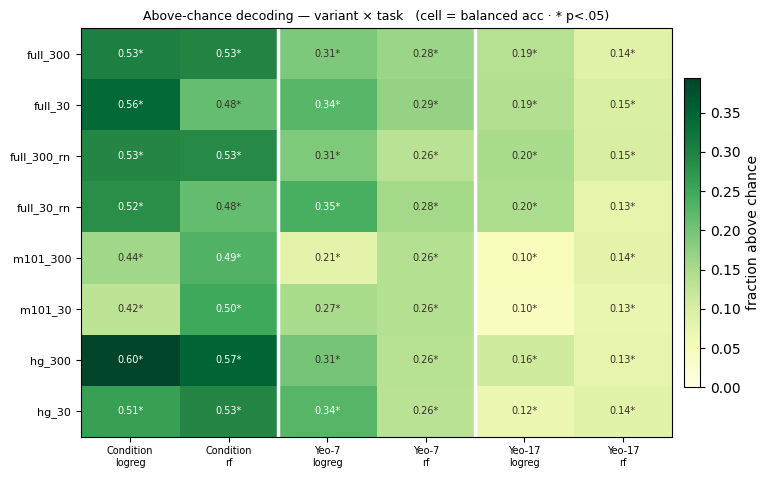

In [2]:
if len(comp): C.plot_compare_heatmap(comp, out_png=outdir/'heatmap.png'); plt.show()


## Fig 2 — Decoding strength, all tasks on one axis
**One condensed panel** (was three). x = **fraction above chance** with **bootstrap 95% CI**
(the error bars). Each **variant** gets a horizontal band; **colour = task**, **marker =
classifier** (● logreg / ■ rf), **filled = p<.05, hollow = ns**. Vertical line at 0 = chance.
Read down a band to compare tasks, across the plot to rank features. Condition decodes
strongest (esp. `hg_300`); Yeo-17 weakest; overlapping CIs = variants you can't separate.


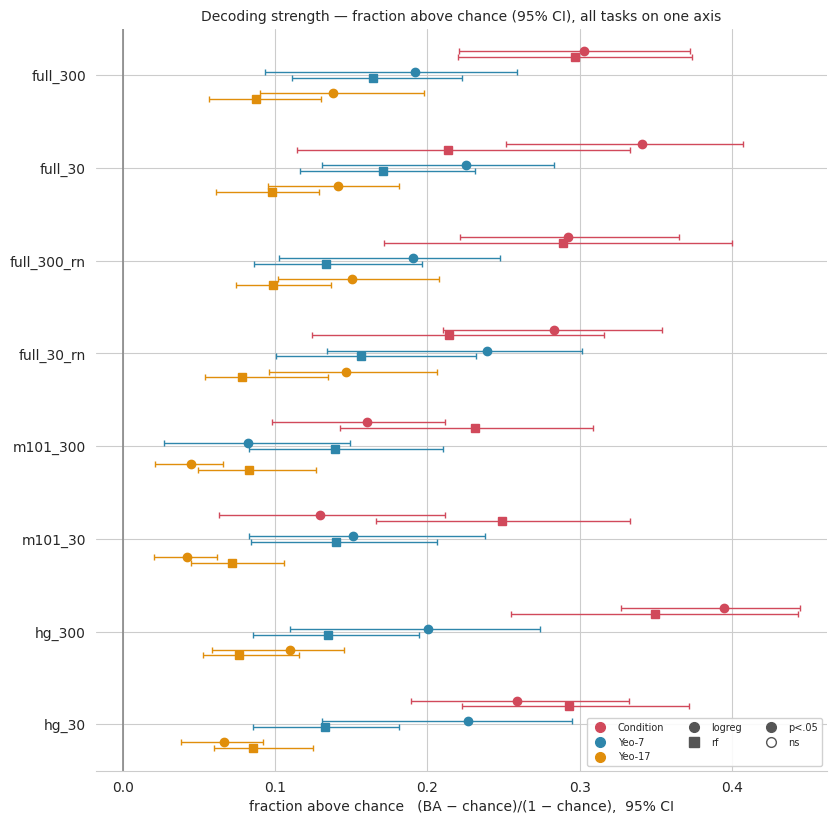

In [3]:
if len(comp): C.plot_compare_forest(comp, out_png=outdir/'forest.png'); plt.show()


## Fig 3 — Paired contrasts (the science)
**Two panels sharing one axis** (was a 2×3 grid). **Colour = task**, **bootstrap 95% CI**
error bars. **Left — amplitude triad** (continuous → row-norm → discretized; solid = 300-time,
dashed = 30-time): a drop left→right means the decode was riding on **power**, not pattern.
**Right — time resolution** (●300 vs ○30) for the full and HG families, paired per task. Read
the *direction*, not the absolute height.


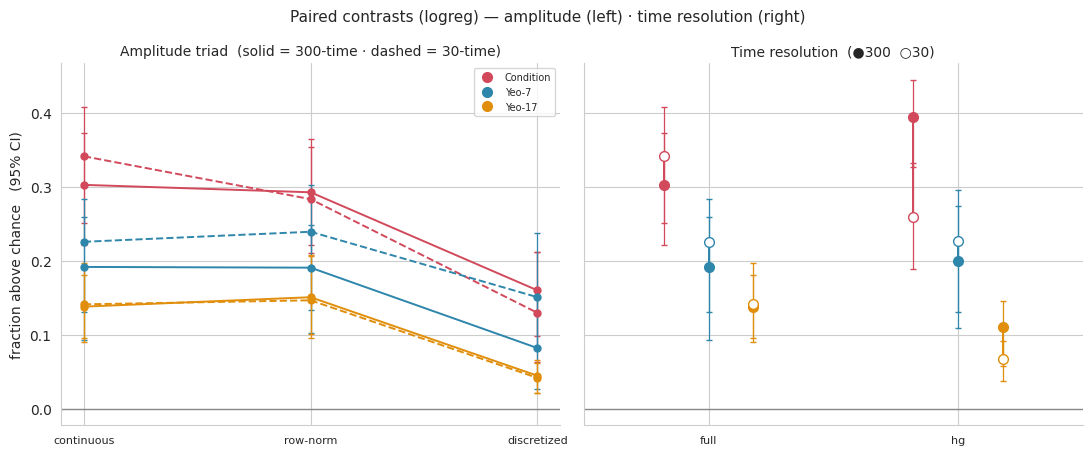

In [4]:
if len(comp): C.plot_paired_contrasts(comp, classifier='logreg', out_png=outdir/'paired_contrasts.png'); plt.show()


## Fig 4 — Paired feature comparison (patient-grouped)

The honest cross-feature comparison: every feature is scored on the **same electrodes with the
same GroupKFold**, so per-patient balanced accuracies are **paired**.

- **Wilcoxon table** — each feature vs a baseline (`full_300`): the per-patient balanced-accuracy
  Δ tested with a signed-rank test over patients. Respects the patient-grouped design (unlike
  McNemar on pooled out-of-fold predictions). With ~N patients it has limited power and
  per-patient accuracy is noisy — a **screen, not proof**.
- **Δ-confusion** — `confusion(feature) − confusion(baseline)`, row-normalised: **red** = the
  feature sends more of a true class to that predicted class than the baseline (blue = less).
  Isolates the *change* in error structure so you don't mentally subtract two matrices.



=== condition · logreg — vs full_300 ===


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\scipy\stats\_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\scipy\stats\_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\scipy\stats\_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\scipy\stats\_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal

,vs_baseline,variant,n_patients,median_delta,wilcoxon_p
0,full_300,full_30,24,0.0049,0.3615
1,full_300,full_300_rn,24,0.0000,0.6009
2,full_300,full_30_rn,24,-0.0010,0.9032
3,full_300,m101_300,24,-0.0621,0.2768
4,full_300,m101_30,24,0.0032,0.5230
5,full_300,hg_300,24,0.0413,0.0340
6,full_300,hg_30,24,-0.0095,0.7843


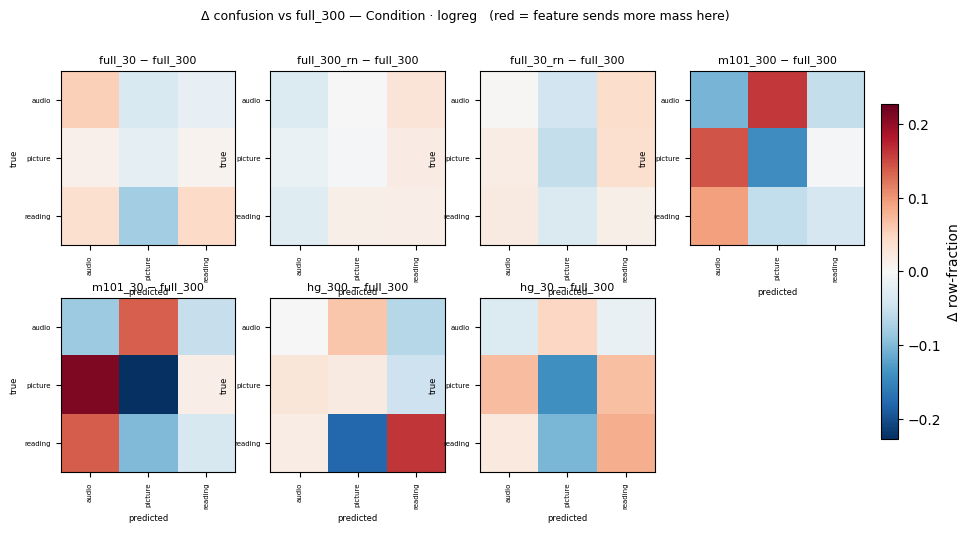


=== parcellation_yeo7 · logreg — vs full_300 ===


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\scipy\stats\_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\scipy\stats\_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\scipy\stats\_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\scipy\stats\_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal

,vs_baseline,variant,n_patients,median_delta,wilcoxon_p
0,full_300,full_30,24,0.0035,0.6265
1,full_300,full_300_rn,24,-0.0007,0.9359
2,full_300,full_30_rn,24,0.0147,0.1485
3,full_300,m101_300,24,-0.1088,0.0003
4,full_300,m101_30,24,-0.0592,0.2015
5,full_300,hg_300,24,-0.0364,0.0803
6,full_300,hg_30,24,-0.0025,0.4115


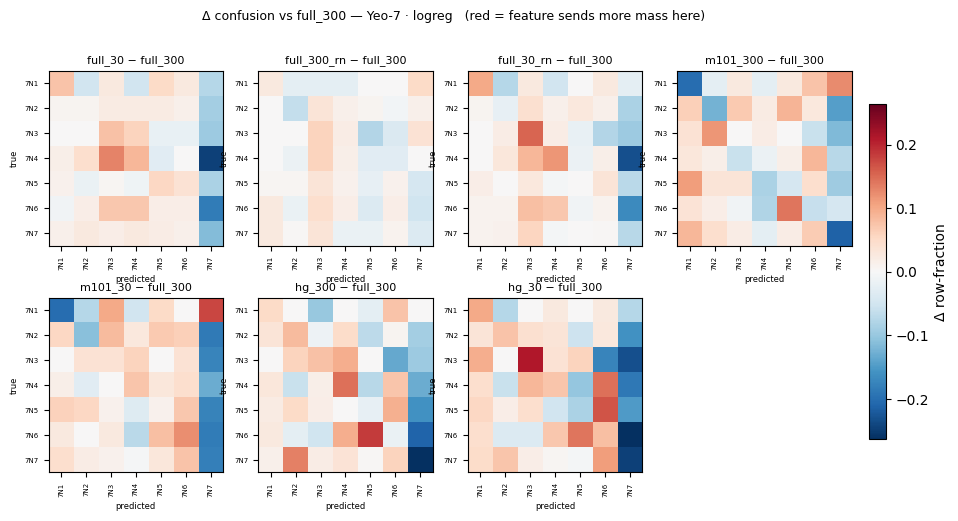


=== parcellation_yeo17 · logreg — vs full_300 ===


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\scipy\stats\_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\scipy\stats\_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\scipy\stats\_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\scipy\stats\_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal

,vs_baseline,variant,n_patients,median_delta,wilcoxon_p
0,full_300,full_30,24,0.0049,0.3896
1,full_300,full_300_rn,24,0.0000,0.6813
2,full_300,full_30_rn,24,0.0000,0.5755
3,full_300,m101_300,24,-0.1111,0.0003
4,full_300,m101_30,24,-0.0971,0.0010
5,full_300,hg_300,24,-0.0234,0.1209
6,full_300,hg_30,24,-0.0996,0.0008


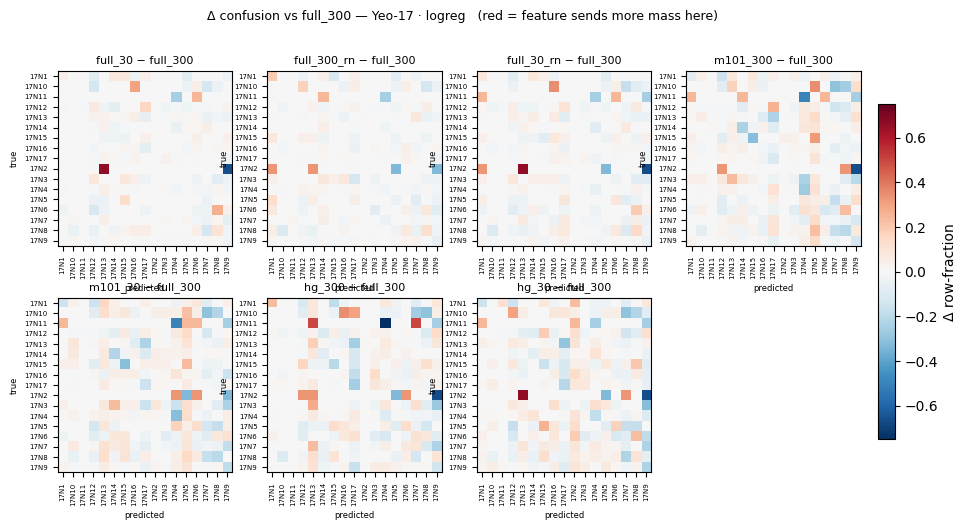

In [5]:
BASELINE = 'full_300'; CLF = 'logreg'
for t in ('condition', 'parcellation_yeo7', 'parcellation_yeo17'):
    print(f'\n=== {t} · {CLF} — vs {BASELINE} ===')
    w = C.paired_feature_wilcoxon(t, CLF, baseline=BASELINE)
    if len(w): display(w.round(4))
    else: print('  no runs')
    fig = C.plot_delta_confusion(t, CLF, baseline=BASELINE, out_png=outdir/f'delta_confusion_{t}.png')
    if fig is not None: plt.show()
    else: print('  (need the baseline + >=1 other feature run)')


## Fig 5 — Classifier agreement (robustness check)
Each point is one (task, variant): x = **above-chance(logreg)**, y = **above-chance(rf)**.
Points on the **diagonal** mean both classifiers reach the same decoding strength (the feature
is robust to model choice); points pulled **off-diagonal** (labelled) depend on the model.
Condition `full_30` / `full_*_rn` sit **below** the line (logreg > rf), while `m101_*` sit
**above** it (rf ≥ logreg).


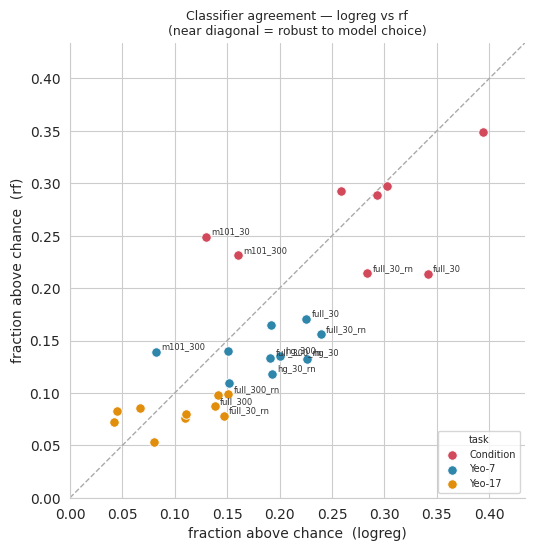

In [6]:
if len(comp): C.plot_compare_clf_scatter(comp, out_png=outdir/'clf_scatter.png'); plt.show()


## Fig 6 — Combined confusion matrices (per task)
The overall-accuracy figures above collapse each confusion matrix to one number; the next two
recover the **class-level** structure. Confusion matrices are only comparable **within** a task
(condition has 3 classes, Yeo-7 has 7, Yeo-17 has 17 — different label sets can't be merged),
so each task gets its own matrix.

**Fig 6** = the **mean row-normalized confusion** across all 16 variant×classifier runs per task:
**diagonal = mean recall**, **off-diagonal = the confusions stable across every feature** (which
network gets mistaken for which). Yeo-17 shows predictions pooling into a few "attractor"
networks (4, 9, 17) — the signature of a hard, imbalanced decode.


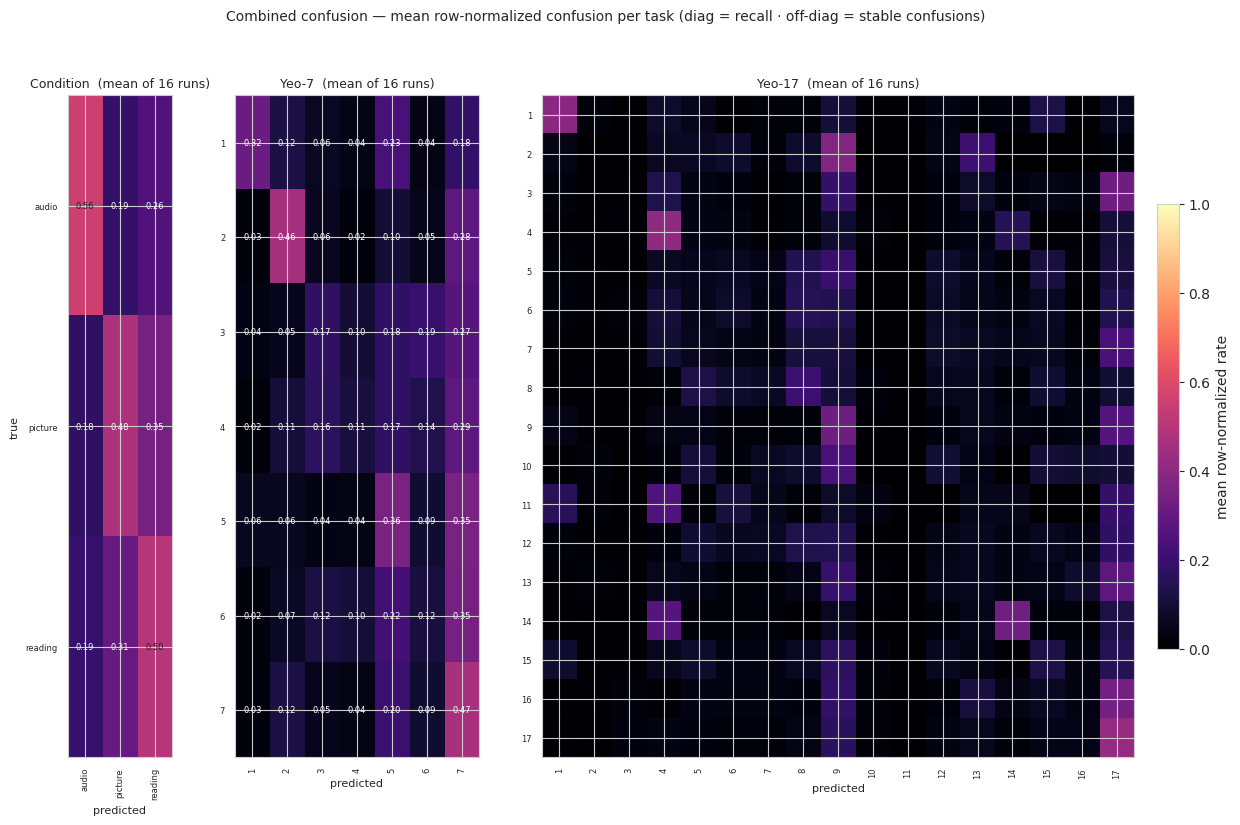

In [7]:
if len(comp): C.plot_confusion_consensus(out_png=outdir/'confusion_consensus.png'); plt.show()


## Fig 7 — Per-class recall (the confusion diagonals, side by side)
The complement to Fig 6: instead of averaging, lay every run's **diagonal** out for comparison.
One stacked heatmap per task — **rows = class, cols = variant·classifier, cell = recall**,
`*` = permutation-FDR p<.05. A row that's pale across the board is a class **no feature decodes**
(chronically confused); a row that brightens for a specific column shows a feature that
selectively recovers that class. Reveals, e.g., that Yeo-17 networks 1/4/14/17 carry almost all
the decodable signal while most others sit near zero.


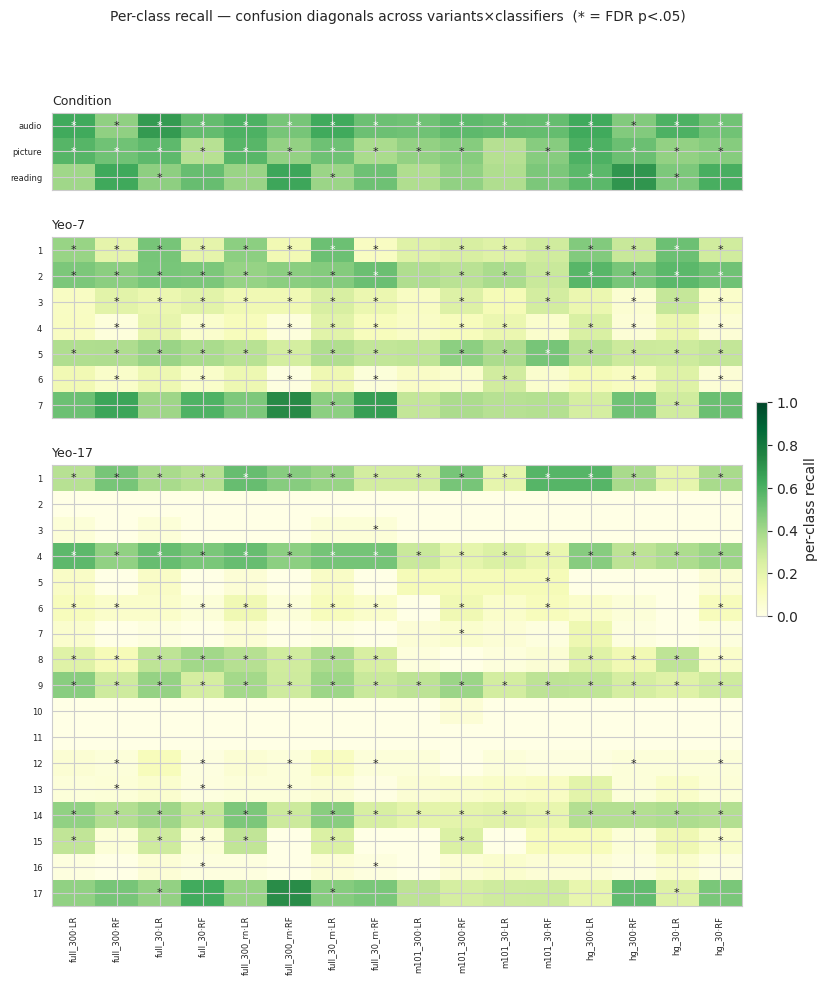

In [8]:
if len(comp): C.plot_class_recall_compare(out_png=outdir/'class_recall_compare.png'); plt.show()


## Analysis — is high-gamma alone as good as the full spectrum?
The variant family was built to answer exactly this: **does the single 70–150 Hz high-gamma
line decode as well as the full 15-band spectrum?** HG and FULL come in **matched pairs** (same
time grid × rownorm × classifier), so this is a *paired* test, run **per task** — the only fair
contrast (they share a time grid by design).

Table below: per-task group means, the median paired Δ (HG−FULL), how many pairs favour HG, a
sign-test + Wilcoxon signed-rank p, and the single **best HG vs best FULL** run (does either win,
and do their 95% CIs overlap?). The slopegraph draws every matched pair — **green rising = HG
higher**.


,task,n_pairs,hg_mean,full_mean,median_d(hg-full),hg_better,sign_p,wilcoxon_p,best_hg,best_full,best_d,best_CIs_overlap
0,Condition,4,0.324,0.289,0.066,3/4,0.625,0.625,hg_300·logreg=0.394,full_30·logreg=0.341,0.053,True
1,Yeo-7,8,0.158,0.184,-0.034,2/8,0.289,0.039,hg_30·logreg=0.227,full_30_rn·logreg=0.239,-0.013,True
2,Yeo-17,8,0.083,0.117,-0.027,0/8,0.008,0.008,hg_300_rn·logreg=0.110,full_300_rn·logreg=0.151,-0.040,True


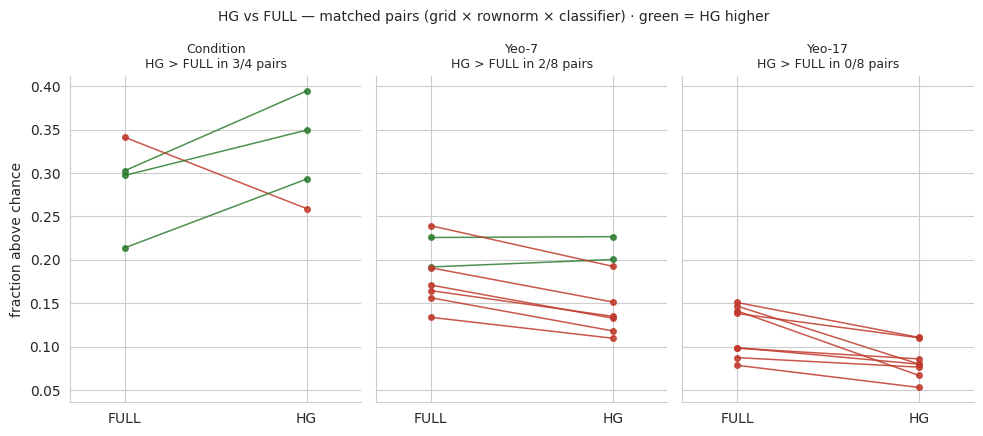

Condition : HG ahead · 3/4 pairs favour HG · median Δ=+0.066 · sign p=0.625, wilcoxon p=0.625 · best HG hg_300·logreg=0.394 vs best FULL full_30·logreg=0.341 (Δ=+0.053) (CIs overlap — n.s. at best-vs-best)
Yeo-7     : FULL ahead · 2/8 pairs favour HG · median Δ=-0.034 · sign p=0.289, wilcoxon p=0.039 · best HG hg_30·logreg=0.227 vs best FULL full_30_rn·logreg=0.239 (Δ=-0.013) (CIs overlap — n.s. at best-vs-best)
Yeo-17    : FULL ahead · 0/8 pairs favour HG · median Δ=-0.027 · sign p=0.008, wilcoxon p=0.008 · best HG hg_300_rn·logreg=0.110 vs best FULL full_300_rn·logreg=0.151 (Δ=-0.040) (CIs overlap — n.s. at best-vs-best)


In [9]:
if len(comp):
    hgf = C.hg_vs_full_stats(comp)
    display(hgf)
    C.plot_hg_vs_full(comp, out_png=outdir/'hg_vs_full.png'); plt.show()
    for _, r in hgf.iterrows():
        lead = 'HG' if r['median_d(hg-full)'] > 0 else 'FULL'
        tie = ' (CIs overlap — n.s. at best-vs-best)' if r['best_CIs_overlap'] else ''
        print(f"{r['task']:10s}: {lead} ahead · {r['hg_better']} pairs favour HG · "
              f"median Δ={r['median_d(hg-full)']:+.3f} · sign p={r['sign_p']}, "
              f"wilcoxon p={r['wilcoxon_p']} · best HG {r['best_hg']} vs best FULL "
              f"{r['best_full']} (Δ={r['best_d']:+.3f}){tie}")
